In [ ]:
import numpy as np # numerical python untuk melakukan manipulation statistics
import pandas as pd #python for data analysis
# %matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.preprocessing import StandardScaler

import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix
warnings.filterwarnings("ignore")

# Visual defaults
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

DATA_DIR = '/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv'

# Data Understanding & Penentuan Goals

Business & Modeling Goals

Goal 1 – Revenue Prediction

* Memprediksi total_revenue per order

* Mengetahui faktor paling berpengaruh terhadap revenue

Goal 2 – Time Series Forecasting

* Memprediksi total revenue di masa depan (bulanan)

* Menangkap tren & seasonality penjualan

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/bootcamp dibimbing/Final Project/Data Science Final Project_DS38+_Miftah Achmanda/amazon_sales_dataset.csv")
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [ ]:
# ukuran data
df.shape

(50000, 13)

In [ ]:
# tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [ ]:
# statistik dasar
df.describe(include="all")

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,730,NaN,6,NaN,NaN,NaN,4,5,NaN,NaN,NaN,NaN
top,NaN,2023-10-19,NaN,Beauty,NaN,NaN,NaN,Asia,Wallet,NaN,NaN,NaN,NaN
freq,NaN,93,NaN,8465,NaN,NaN,NaN,12526,10106,NaN,NaN,NaN,NaN
mean,25000.500000,NaN,2986.848740,NaN,252.507260,13.340700,2.999400,NaN,NaN,2.996316,249.329280,218.886566,657.331475
std,14433.901067,NaN,1156.374535,NaN,143.025544,9.850694,1.415401,NaN,NaN,1.154295,144.251981,127.317681,526.223968
min,1.000000,NaN,1000.000000,NaN,5.010000,0.000000,1.000000,NaN,NaN,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,NaN,1983.000000,NaN,127.840000,5.000000,2.000000,NaN,NaN,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,NaN,2983.000000,NaN,252.970000,10.000000,3.000000,NaN,NaN,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,NaN,3989.000000,NaN,376.335000,20.000000,4.000000,NaN,NaN,4.000000,374.000000,322.702500,968.970000


# Data Cleaning

## Konversi Tipe Data Order date

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

## Cek Missing Values

In [ ]:
# cek null
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


## Cek Duplikasi

In [ ]:
df.duplicated(subset="order_id").sum()

np.int64(0)

In [ ]:
# df = df.drop_duplicates(subset="order_id")

## Cek Outlier

In [ ]:
def detect_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Total Outliers : {outliers.shape[0]}")

    return outliers

In [ ]:
outlier_price = detect_outlier_iqr(df, "price")
outlier_revenue = detect_outlier_iqr(df, "total_revenue")
outlier_quantity = detect_outlier_iqr(df, "quantity_sold")

price
Lower Bound : -244.90249999999995
Upper Bound : 749.0774999999999
Total Outliers : 0
total_revenue
Lower Bound : -852.6550000000002
Upper Bound : 2061.945
Total Outliers : 752
quantity_sold
Lower Bound : -1.0
Upper Bound : 7.0
Total Outliers : 0


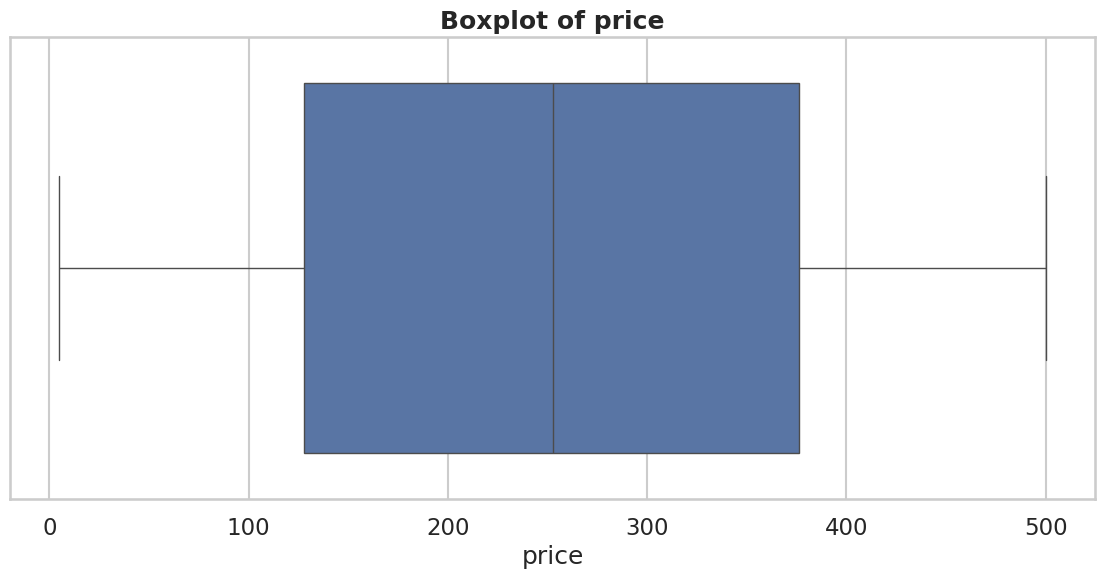

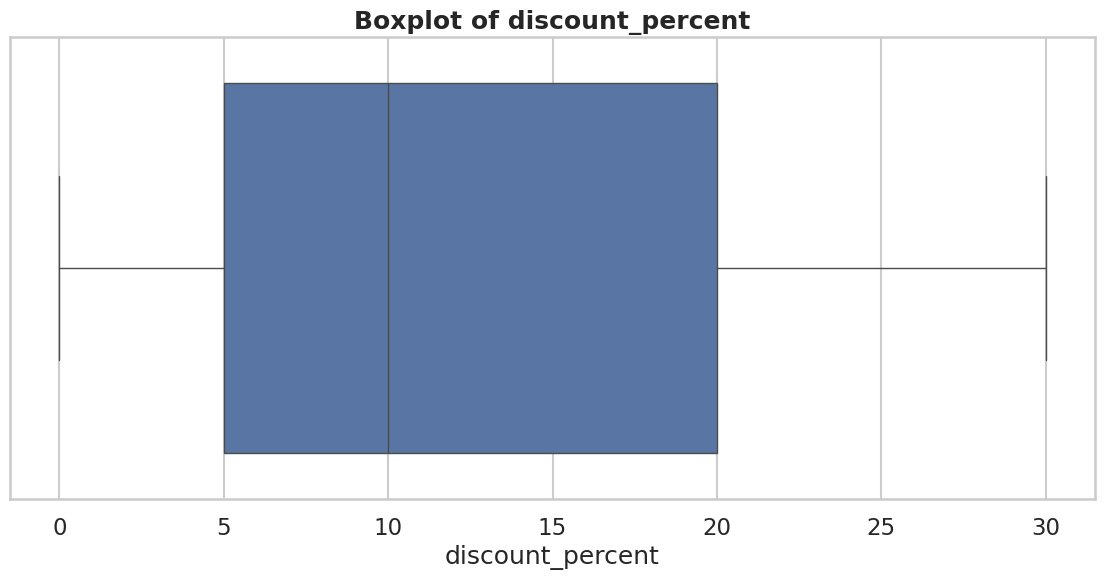

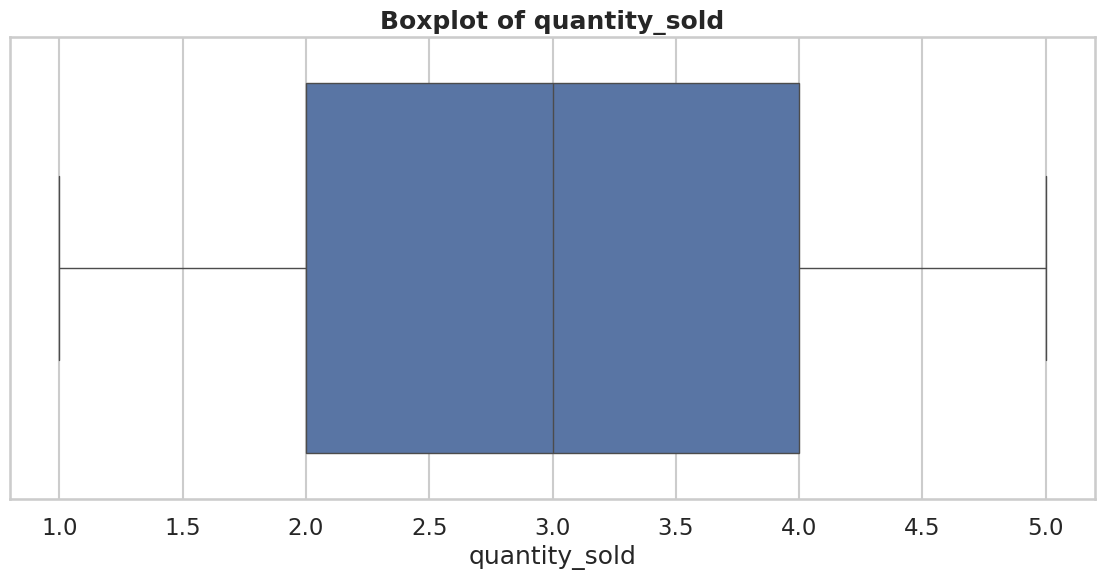

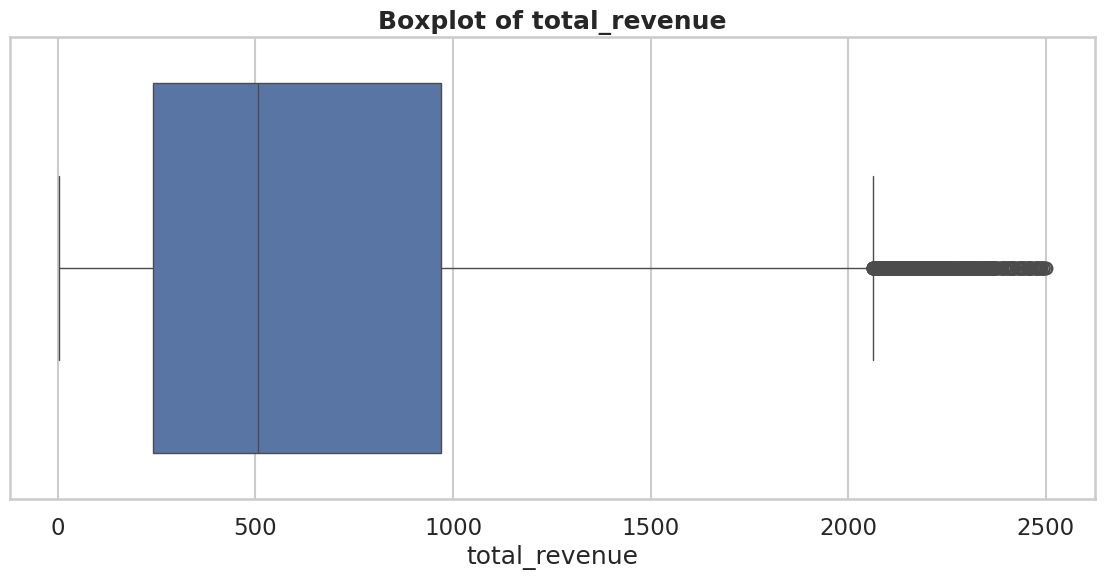

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["price", "discount_percent", "quantity_sold", "total_revenue"]

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Outlier analysis menunjukkan bahwa harga dan jumlah pembelian berada dalam rentang normal.
Outlier hanya ditemukan pada total revenue, yang merepresentasikan transaksi bernilai tinggi dan masih relevan secara bisnis.

## Validasi Data

In [ ]:
# discounted price tidak boleh lebih besar dari price
df = df[df["discounted_price"] <= df["price"]]

# total_revenue harus sesuai
df["revenue_check"] = df["discounted_price"] * df["quantity_sold"]

df = df[np.isclose(df["total_revenue"], df["revenue_check"], atol=1)]
df.drop(columns="revenue_check", inplace=True)

# Data Manipulation (Feature Engineering)

In [ ]:
# fitur waktu
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day_of_week"] = df["order_date"].dt.day_name()


In [ ]:
# flag diskon
df["discount_flag"] = np.where(df["discount_percent"] > 0, 1, 0)

# EDA (Exploratory Data Analysis)

## Distribusi Total Revenue

In [ ]:
df["total_revenue"].describe()

,total_revenue
count,50000.000000
mean,657.331475
std,526.223968
min,3.840000
25%,240.320000
50%,505.410000
75%,968.970000
max,2499.550000


In [ ]:
df["total_revenue"].agg(["mean", "median", "std", "min", "max", "skew"])

,total_revenue
mean,657.331475
median,505.410000
std,526.223968
min,3.840000
max,2499.550000
skew,0.978282


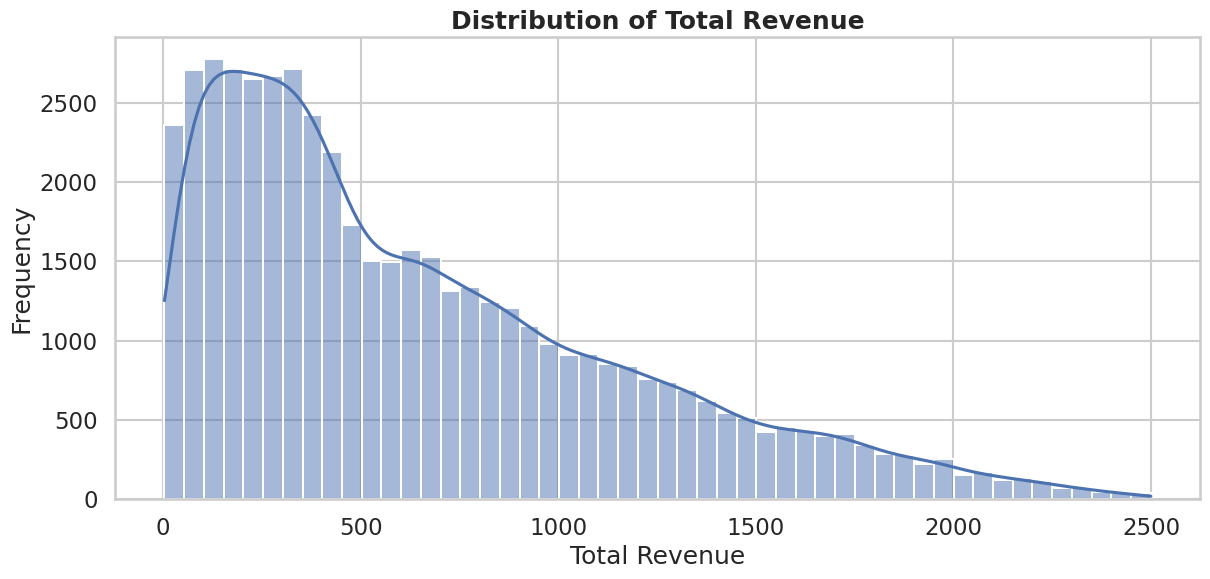

In [ ]:
plt.figure()
sns.histplot(df["total_revenue"], bins=50, kde=True)
plt.title("Distribution of Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.show()

## Top product Category

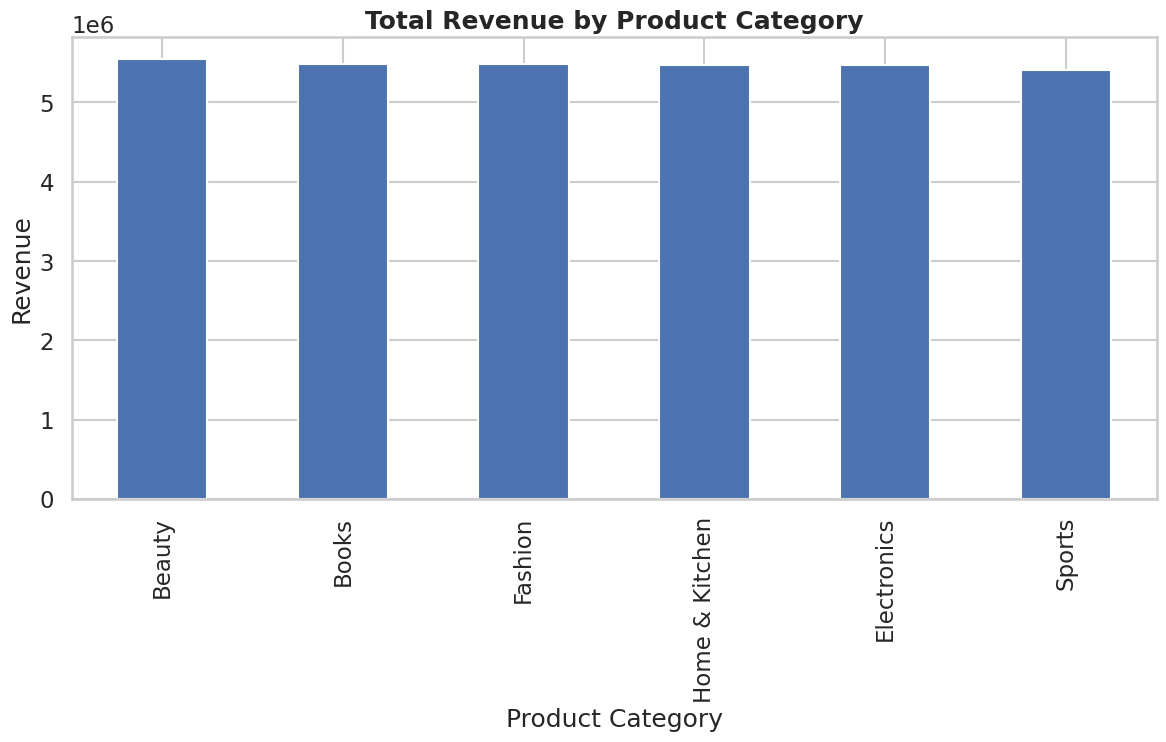

In [ ]:
category_revenue = (
    df.groupby("product_category")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
category_revenue.plot(kind="bar")
plt.title("Total Revenue by Product Category")
plt.ylabel("Revenue")
plt.xlabel("Product Category")
plt.show()

In [ ]:
category_revenue = (
    df.groupby("product_category")
      .agg(
          total_revenue=("total_revenue", "sum"),
          avg_revenue=("total_revenue", "mean"),
          total_quantity=("quantity_sold", "sum"),
          total_orders=("order_id", "count")
      )
      .sort_values("total_revenue", ascending=False)
)

category_revenue

,total_revenue,avg_revenue,total_quantity,total_orders
product_category,,,,
Beauty,5550624.97,655.714704,25422,8465
Books,5484863.03,658.684164,25065,8327
Fashion,5480123.34,655.125325,25089,8365
Home & Kitchen,5473132.55,662.767323,24743,8258
Electronics,5470594.03,657.523321,24898,8320
Sports,5407235.82,654.233009,24753,8265


## Korelasi Quantity Sold vs Revenue

Apakah quantity sold berpengaruh ke revenue?

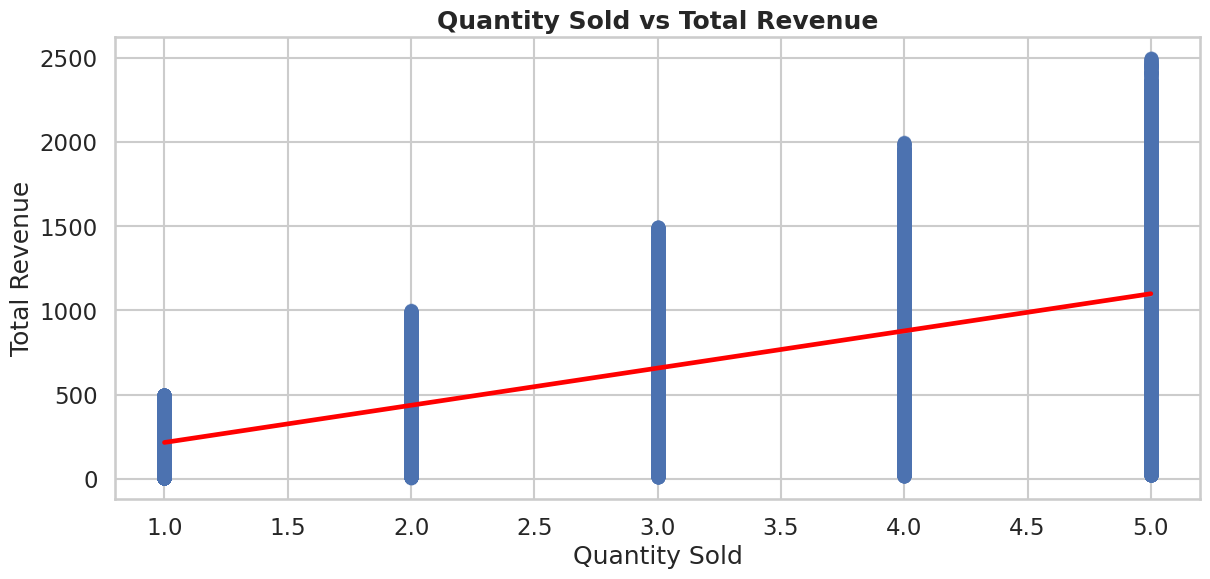

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.regplot(
    x="quantity_sold",
    y="total_revenue",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Quantity Sold vs Total Revenue")
plt.xlabel("Quantity Sold")
plt.ylabel("Total Revenue")
plt.show()

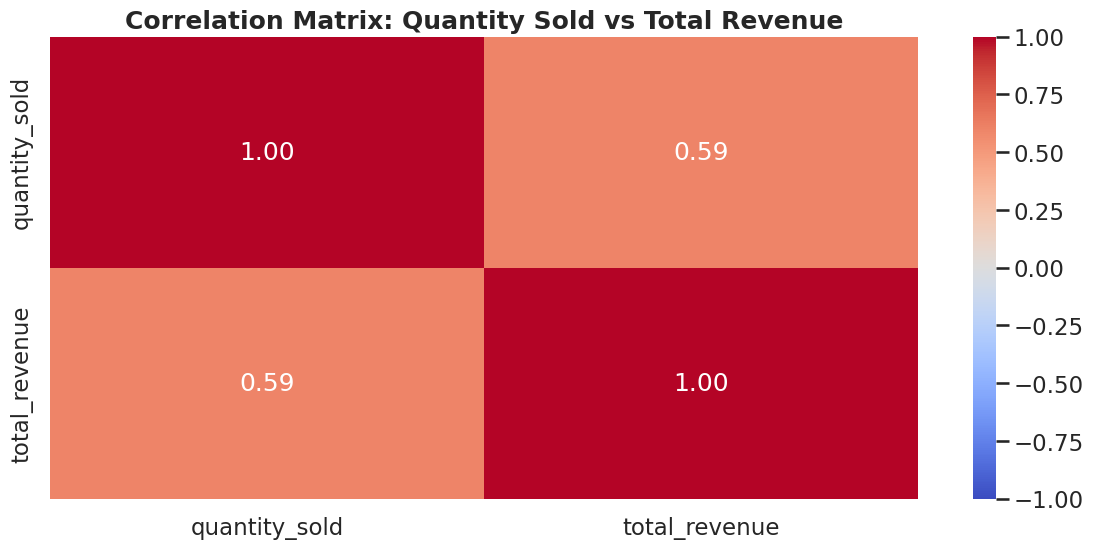

In [ ]:
plt.figure()
corr = df[["quantity_sold", "total_revenue"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Quantity Sold vs Total Revenue")
plt.show()

In [ ]:
df[["quantity_sold", "total_revenue"]].corr()

,quantity_sold,total_revenue
quantity_sold,1.000000,0.594404
total_revenue,0.594404,1.000000


insight interpretasi analisi

* Pola naik jelas artinya korelasi positif
* dipengaruhi harga & diskon

## Discount Analysis

Revenue untuk Diskon vs Non-Diskon

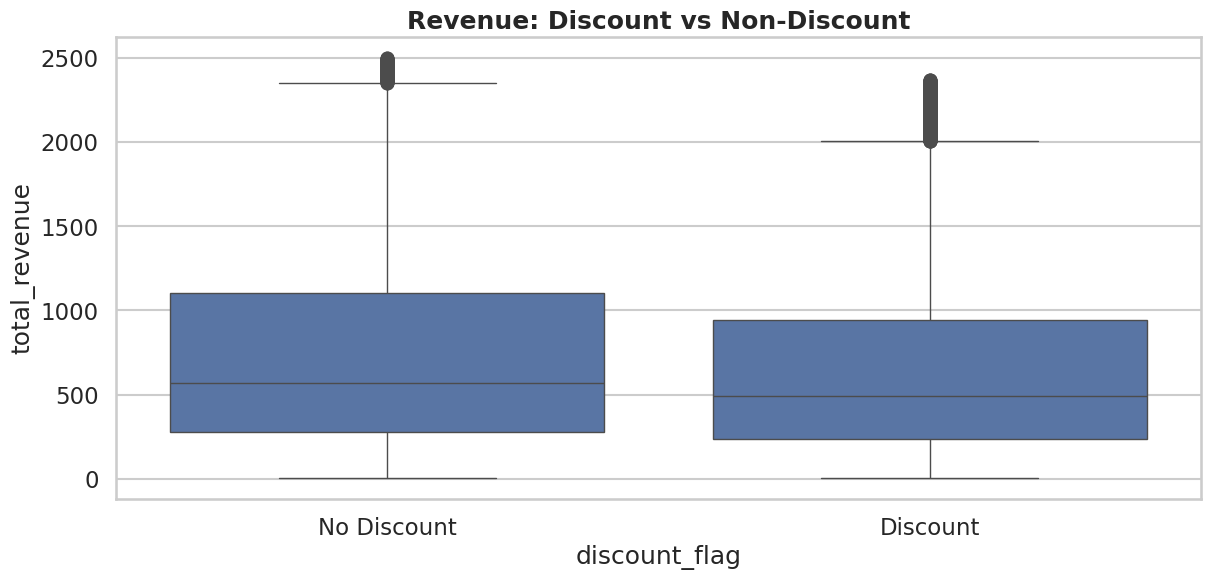

In [ ]:
df["discount_flag"] = (df["discount_percent"] > 0).astype(int)

plt.figure()
sns.boxplot(x="discount_flag", y="total_revenue", data=df)
plt.xticks([0,1], ["No Discount", "Discount"])
plt.title("Revenue: Discount vs Non-Discount")
plt.show()

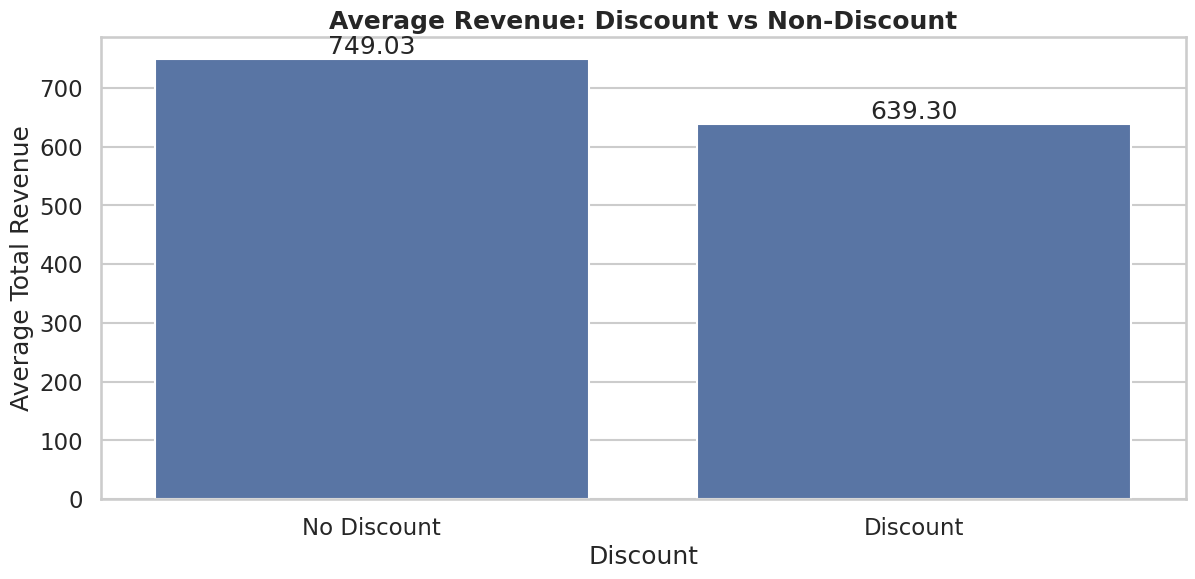

In [ ]:
plt.figure()
ax = sns.barplot(
    x="discount_flag",
    y="total_revenue",
    data=df,
    estimator="mean",
    ci=None
)

plt.xticks([0, 1], ["No Discount", "Discount"])
plt.title("Average Revenue: Discount vs Non-Discount")
plt.xlabel("Discount")
plt.ylabel("Average Total Revenue")

# tampilkan angka di atas bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

insigt  hasil : transaksi non diskon menghasilkan revenue rata-rata lebih tinggi

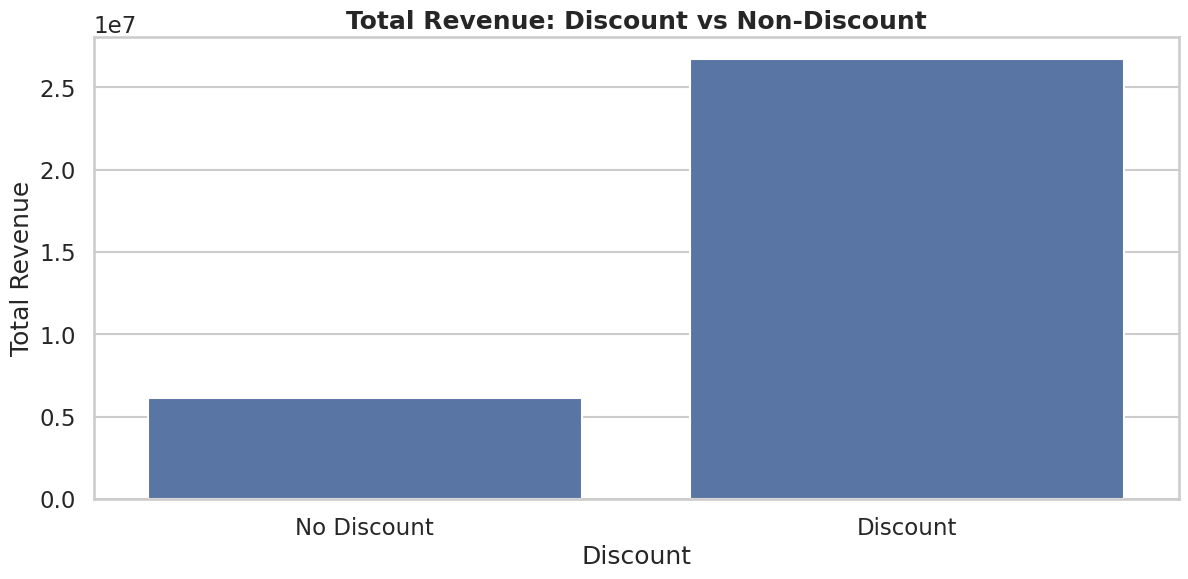

In [ ]:
plt.figure()
sns.barplot(
    x="discount_flag",
    y="total_revenue",
    data=df,
    estimator=sum,
    ci=None
)

plt.xticks([0, 1], ["No Discount", "Discount"])
plt.title("Total Revenue: Discount vs Non-Discount")
plt.xlabel("Discount")
plt.ylabel("Total Revenue")
plt.show()

insight : berdasarkan total revenue, diskon menunjukan total revenue yang tinggi dibanding dengan non diskon

In [ ]:
discount_revenue = (
    df.groupby("discount_flag")
      .agg(
          avg_revenue=("total_revenue", "mean"),
          median_revenue=("total_revenue", "median"),
          total_revenue=("total_revenue", "sum"),
          avg_quantity=("quantity_sold", "mean"),
          total_orders=("order_id", "count")
      )
)

discount_revenue.index = ["No Discount", "Discount"]
discount_revenue

,avg_revenue,median_revenue,total_revenue,avg_quantity,total_orders
No Discount,749.033022,570.21,6154055.31,2.986490,8216
Discount,639.300173,493.20,26712518.43,3.001939,41784


Dampak Diskon terhadap Quantity Sold

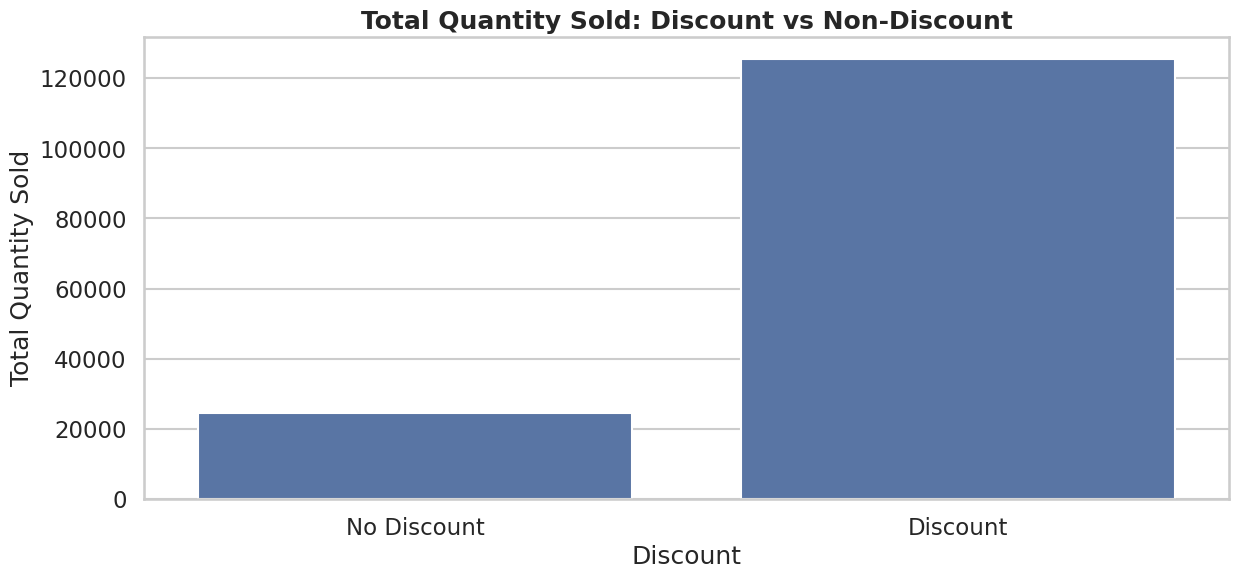

In [ ]:
plt.figure()
sns.barplot(
    x="discount_flag",
    y="quantity_sold",
    data=df,
    estimator=sum,
    ci=None
)

plt.xticks([0, 1], ["No Discount", "Discount"])
plt.title("Total Quantity Sold: Discount vs Non-Discount")
plt.xlabel("Discount")
plt.ylabel("Total Quantity Sold")
plt.show()

In [ ]:
df.groupby("discount_flag")["quantity_sold"].describe()

,count,mean,std,min,25%,50%,75%,max
discount_flag,,,,,,,,
0,8216.0,2.986490,1.403391,1.0,2.0,3.0,4.0,5.0
1,41784.0,3.001939,1.417753,1.0,2.0,3.0,4.0,5.0


## Regional Analysis

Revenue per Region

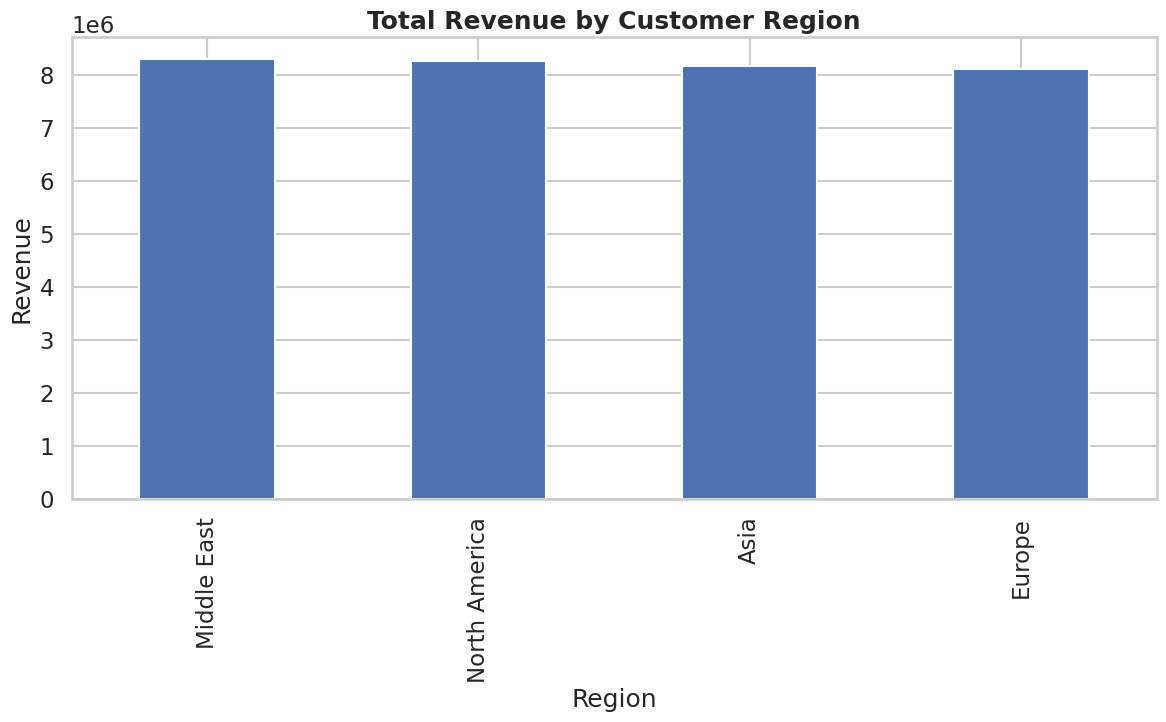

In [ ]:
region_revenue = (
    df.groupby("customer_region")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
region_revenue.plot(kind="bar")
plt.title("Total Revenue by Customer Region")
plt.ylabel("Revenue")
plt.xlabel("Region")
plt.show()

In [ ]:
region_revenue = (
    df.groupby("customer_region")
      .agg(
          total_revenue=("total_revenue", "sum"),
          avg_revenue=("total_revenue", "mean"),
          total_orders=("order_id", "count")
      )
      .sort_values("total_revenue", ascending=False)
)

region_revenue

,total_revenue,avg_revenue,total_orders
customer_region,,,
Middle East,8301844.50,663.882007,12505
North America,8277217.84,661.278089,12517
Asia,8175199.83,652.658457,12526
Europe,8112311.57,651.486634,12452


Preferensi Payment Method per Region

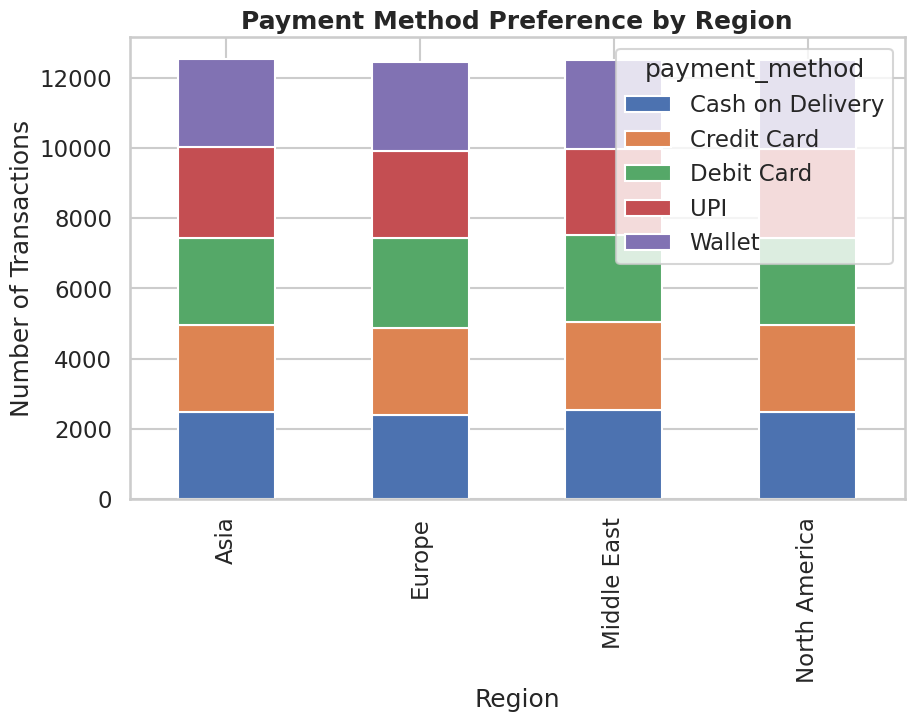

In [ ]:
payment_region = (
    df.groupby(["customer_region", "payment_method"])
    .size()
    .unstack(fill_value=0)
)

payment_region.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Payment Method Preference by Region")
plt.ylabel("Number of Transactions")
plt.xlabel("Region")
plt.show()

In [ ]:
payment_region = (
    df.groupby(["customer_region", "payment_method"])
      .size()
      .unstack(fill_value=0)
)

payment_region

payment_method,Cash on Delivery,Credit Card,Debit Card,UPI,Wallet
customer_region,,,,,
Asia,2487,2486,2451,2606,2496
Europe,2411,2468,2551,2478,2544
Middle East,2544,2493,2486,2456,2526
North America,2485,2461,2493,2538,2540


In [ ]:
payment_region_pct = payment_region.div(payment_region.sum(axis=1), axis=0) * 100
payment_region_pct.round(2)

payment_method,Cash on Delivery,Credit Card,Debit Card,UPI,Wallet
customer_region,,,,,
Asia,19.85,19.85,19.57,20.80,19.93
Europe,19.36,19.82,20.49,19.90,20.43
Middle East,20.34,19.94,19.88,19.64,20.20
North America,19.85,19.66,19.92,20.28,20.29


## Customer Feedback Analysis

Korelasi Rating vs Total Revenue

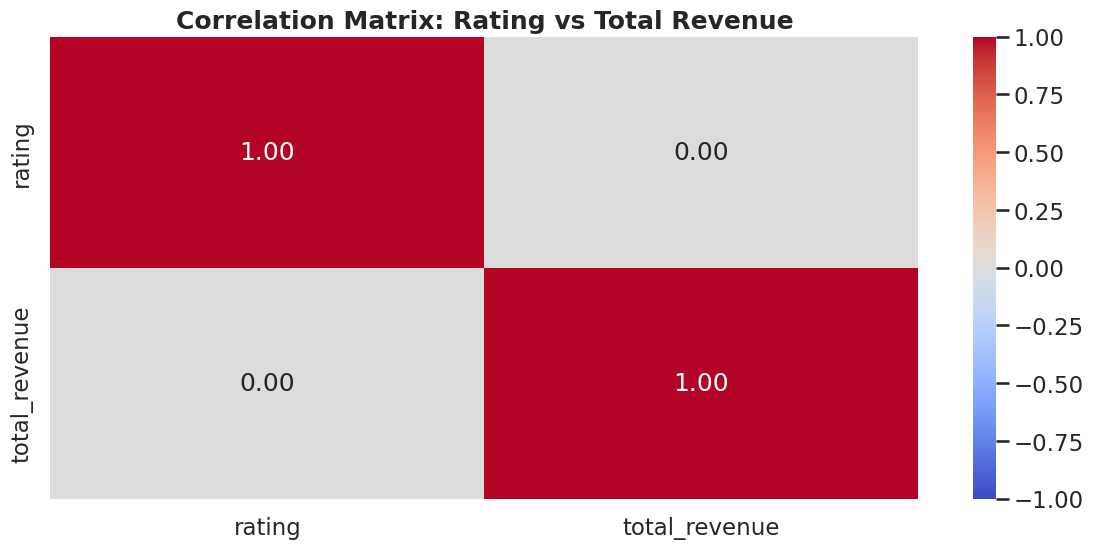

In [ ]:
plt.figure()
corr = df[["rating", "total_revenue"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Rating vs Total Revenue")
plt.show()

In [ ]:
df[["rating", "total_revenue"]].corr()


,rating,total_revenue
rating,1.000000,0.001804
total_revenue,0.001804,1.000000


In [ ]:
rating_revenue = (
    df.groupby("rating")
      .agg(
          avg_revenue=("total_revenue", "mean"),
          total_revenue=("total_revenue", "sum"),
          total_orders=("order_id", "count")
      )
)

rating_revenue

,avg_revenue,total_revenue,total_orders
rating,,,
1.0,661.671773,402958.11,609
1.1,661.816876,802783.87,1213
1.2,635.169714,800313.84,1260
1.3,676.833624,831151.69,1228
1.4,649.217066,807626.03,1244
1.5,690.850936,900178.77,1303
1.6,642.936936,828745.71,1289
1.7,672.190032,844270.68,1256
1.8,658.483640,823104.55,1250


note insight : Rating tinggi tidak sama dengan revenue tinggi

## Time Series EDA

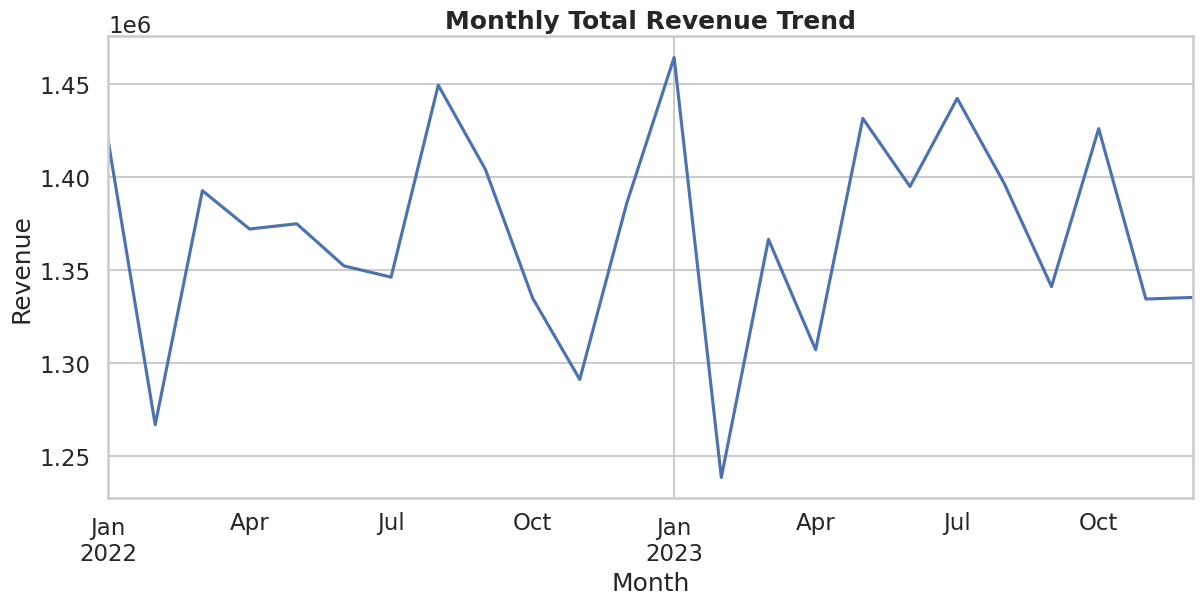

In [ ]:
monthly_revenue = (
    df.set_index("order_date")
      .resample("M")["total_revenue"]
      .sum()
)

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Total Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

In [ ]:
'''monthly_revenue = (
    df.set_index("order_date")
      .resample("M")["total_revenue"]
      .sum()
)

monthly_revenue.head()'''

'monthly_revenue = (\n    df.set_index("order_date")\n      .resample("M")["total_revenue"]\n      .sum()\n)\n\nmonthly_revenue.head()'

Seasonality

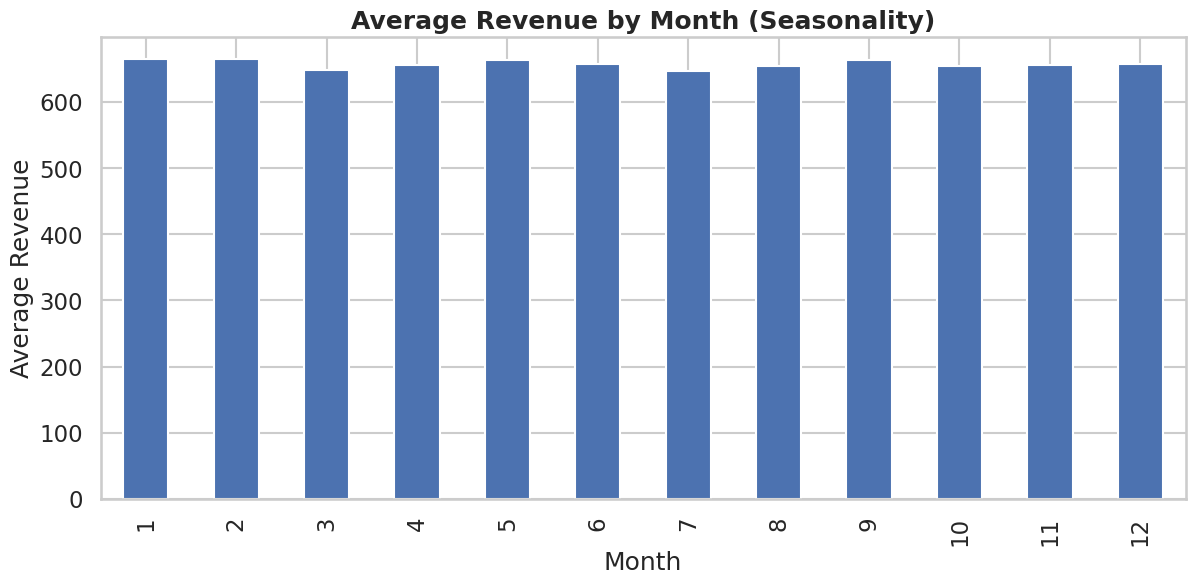

In [ ]:
monthly_avg = (
    df.groupby(df["order_date"].dt.month)["total_revenue"]
    .mean()
)

plt.figure()
monthly_avg.plot(kind="bar")
plt.title("Average Revenue by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
monthly_avg = (
    df.groupby(df["order_date"].dt.month)["total_revenue"]
      .mean()
)

monthly_avg.sort_values(ascending=False)

,total_revenue
order_date,
2,665.187148
1,664.805643
9,664.160397
5,663.869965
12,657.977500
6,657.793970
4,655.647031
11,655.374069
10,654.362252


peak month :

In [ ]:
monthly_avg.idxmax(), monthly_avg.max()

(np.int32(2), 665.1871481678172)

low month :

In [ ]:
monthly_avg.idxmin(), monthly_avg.min()

(np.int32(7), 647.0795637038756)

Fluktuasi Penjualan

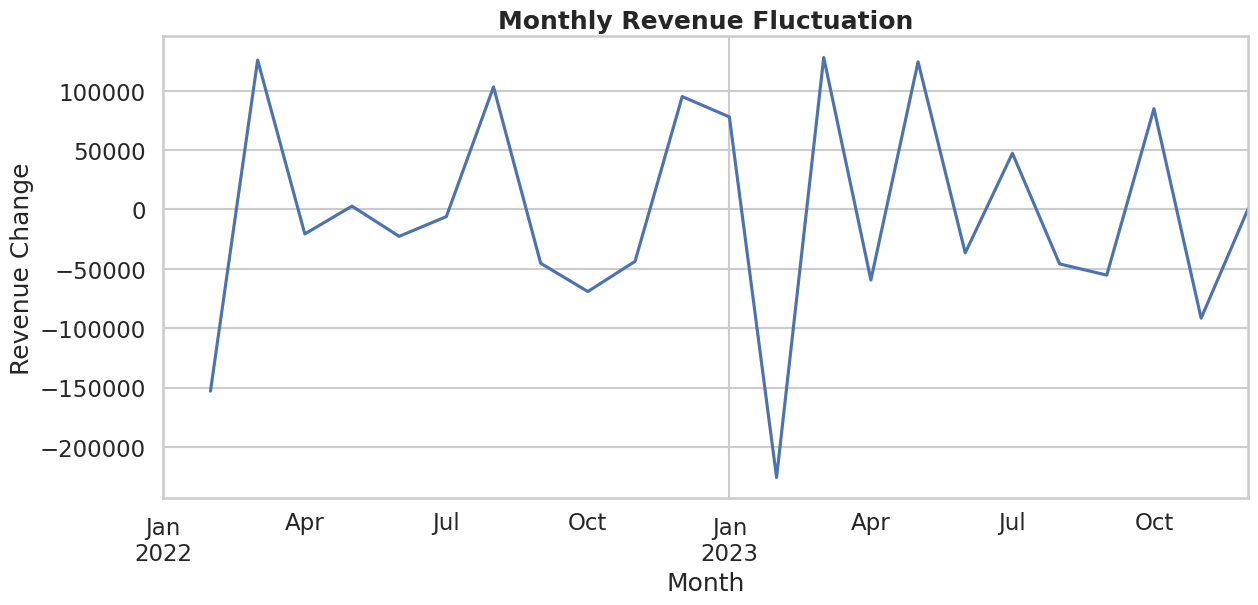

In [ ]:
plt.figure()
monthly_revenue.diff().plot()
plt.title("Monthly Revenue Fluctuation")
plt.ylabel("Revenue Change")
plt.xlabel("Month")
plt.show()

In [ ]:
monthly_revenue_diff = monthly_revenue.diff()

monthly_revenue_diff.describe()

,total_revenue
count,23.000000
mean,-3676.806957
std,91747.562559
min,-225794.480000
25%,-50584.400000
50%,-20629.590000
75%,81446.875000
max,128037.900000


In [ ]:
summary = {
    "Total Revenue": df["total_revenue"].sum(),
    "Average Revenue per Order": df["total_revenue"].mean(),
    "Total Orders": df["order_id"].nunique(),
    "Top Category": category_revenue.index[0],
    "Top Region": region_revenue.index[0],
    "Revenue Discount vs Non-Discount": discount_revenue["total_revenue"].to_dict(),
    "Rating-Revenue Correlation": df[["rating","total_revenue"]].corr().iloc[0,1]
}

summary

{'Total Revenue': np.float64(32866573.74),
 'Average Revenue per Order': np.float64(657.3314748),
 'Total Orders': 50000,
 'Top Category': 'Beauty',
 'Top Region': 'Middle East',
 'Revenue Discount vs Non-Discount': {'No Discount': 6154055.31,
  'Discount': 26712518.43},
 'Rating-Revenue Correlation': np.float64(0.0018039838958107558)}

# Modeling Data Science Model

# Goal 1 – Revenue Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.50
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.63
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## split data set

In [ ]:
#split data set
# drop kolom ID dan Tanggal karena fokus pada karakteristik transaksi
X = df.drop(columns=['total_revenue', 'order_id', 'order_date', 'product_id', 'discounted_price', 'revenue_check'], errors='ignore')
y = df['total_revenue']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## EDA (Correlation pada Train Set)

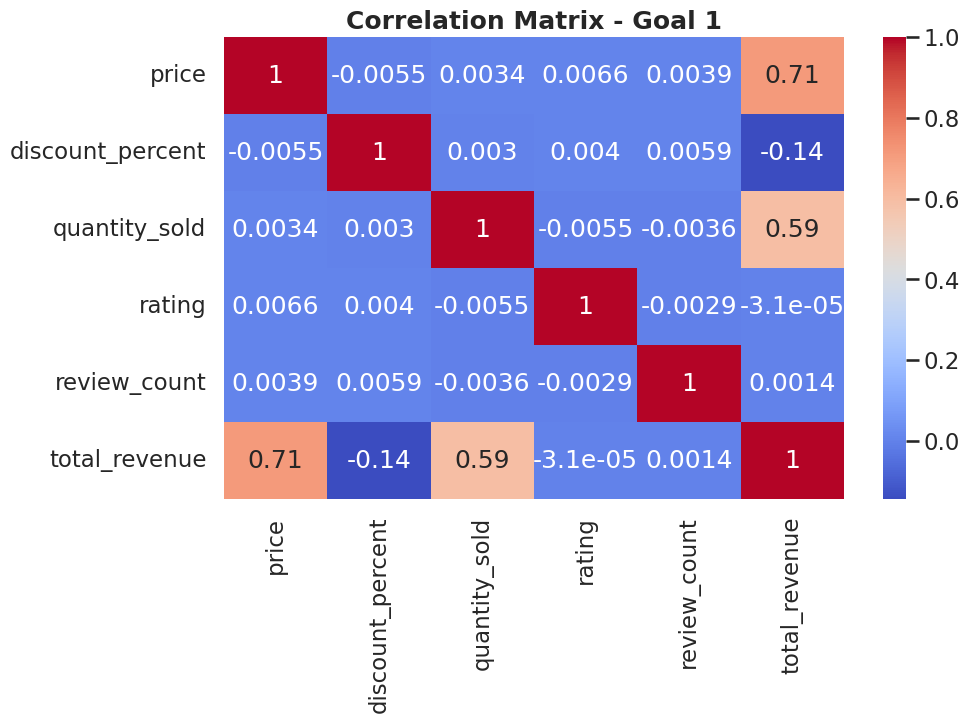

In [ ]:
# EDA (Correlation pada Train Set)
plt.figure(figsize=(10, 6))
sns.heatmap(pd.concat([x_train, y_train], axis=1).select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - Goal 1")
plt.show()

## FEATURE ENGINEERING (Scaling & Encoding)

In [ ]:
# Numerical Scaling
scaler = StandardScaler()
num_cols = x_train.select_dtypes(include=[np.number]).columns
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train[num_cols]), columns=num_cols, index=x_train.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test[num_cols]), columns=num_cols, index=x_test.index)


In [ ]:
# Categorical Encoding (OneHot)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_cols = x_train.select_dtypes(include=['object']).columns
x_train_encoded = pd.DataFrame(encoder.fit_transform(x_train[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=x_train.index)
x_test_encoded = pd.DataFrame(encoder.transform(x_test[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=x_test.index)

In [ ]:
x_train_final = pd.concat([x_train_scaled, x_train_encoded], axis=1)
x_test_final = pd.concat([x_test_scaled, x_test_encoded], axis=1)

FEATURE SELECTION

In [ ]:
# Menggunakan Random Forest untuk memilih fitur terpenting
selector_model = RandomForestRegressor(n_estimators=50, random_state=42)
selector_model.fit(x_train_final, y_train)
selector = SelectFromModel(selector_model, threshold="mean", prefit=True)

x_train_sel = x_train_final.loc[:, selector.get_support()]
x_test_sel = x_test_final.loc[:, selector.get_support()]

print(f"Fitur Terpilih: {x_train_sel.columns.tolist()}")

Fitur Terpilih: ['price', 'quantity_sold']


In [ ]:
# Melatih 3 Model Machine Learning
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    metrics_df = pd.DataFrame({
        'Model': [model_name],
        'MAE': [mae],
        'MSE': [mse],
        'RMSE': [rmse],
        'R2': [r2],
        'MAPE (%)': [mape * 100]
    })

    return metrics_df

report_goal1 = pd.DataFrame()
for name, model in models.items():
    model.fit(x_train_sel, y_train)
    report_goal1 = pd.concat([report_goal1, evaluate_model(y_test, model.predict(x_test_sel), name)])

print("HASIL EVALUASI GOAL 1")
print(report_goal1)

HASIL EVALUASI GOAL 1
           Model        MAE           MSE        RMSE        R2   MAPE (%)
0  Decision Tree  65.248552   9567.058402   97.811341  0.964716  10.908414
0  Random Forest  74.221458  13205.122897  114.913545  0.951298  11.811914
0        XGBoost  64.195954   9246.560805   96.159039  0.965898  10.274336


## HYPERPARAMETER

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    scoring='r2', # menggunakan R2 karena ini masalah regresi
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train_sel, y_train)

print("Best Parameters RF:", grid_rf.best_params_)
print("Best R2 Score CV:", grid_rf.best_score_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best R2 Score CV: 0.9671296149047195


In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(x_train_sel, y_train)

print("Best Parameters XGB:", grid_xgb.best_params_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters XGB: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
# Mengambil model terbaik hasil tuning
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

# Buat tabel perbandingan (Baseline vs Tuned)
report_comparison = pd.concat([
    evaluate_model(y_test, models["Random Forest"].predict(x_test_sel), "RF Baseline"),
    evaluate_model(y_test, best_rf.predict(x_test_sel), "RF Tuned"),
    evaluate_model(y_test, models["XGBoost"].predict(x_test_sel), "XGB Baseline"),
    evaluate_model(y_test, best_xgb.predict(x_test_sel), "XGB Tuned")
]).reset_index(drop=True)

print(report_comparison)

          Model        MAE           MSE        RMSE        R2   MAPE (%)
0   RF Baseline  74.221458  13205.122897  114.913545  0.951298  11.811914
1      RF Tuned  64.400501   9347.271638   96.681289  0.965526  10.336060
2  XGB Baseline  64.195954   9246.560805   96.159039  0.965898  10.274336
3     XGB Tuned  64.242164   9182.263016   95.824125  0.966135  11.023234


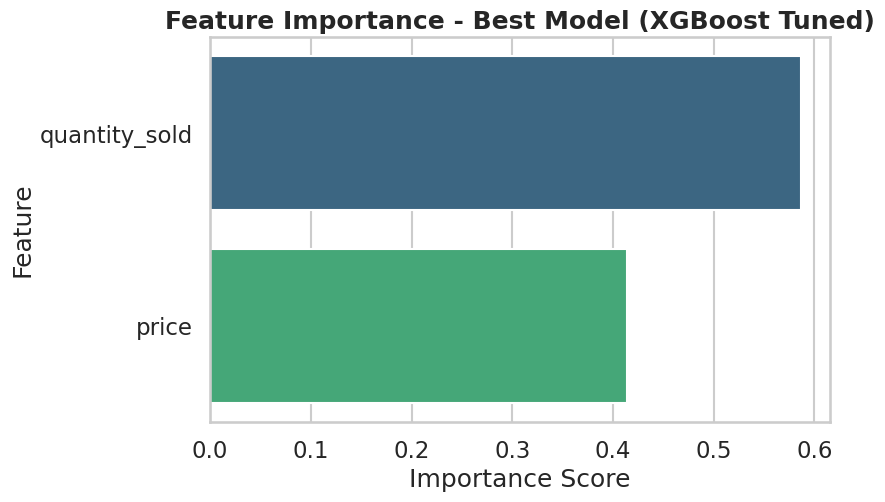

Fitur Paling Berpengaruh:
         Feature  Importance
1  quantity_sold    0.586466
0          price    0.413534


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance dari Model Terbaik (XGBoost Tuned)

best_model = grid_xgb.best_estimator_

importance_scores = best_model.feature_importances_
feature_names = x_train_sel.columns

# Membuat DataFrame untuk mempermudah plotting
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# 3. Faktor Paling Berpengaruh terhadap Revenue
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')

plt.title('Feature Importance - Best Model (XGBoost Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("Fitur Paling Berpengaruh:")
print(df_importance)

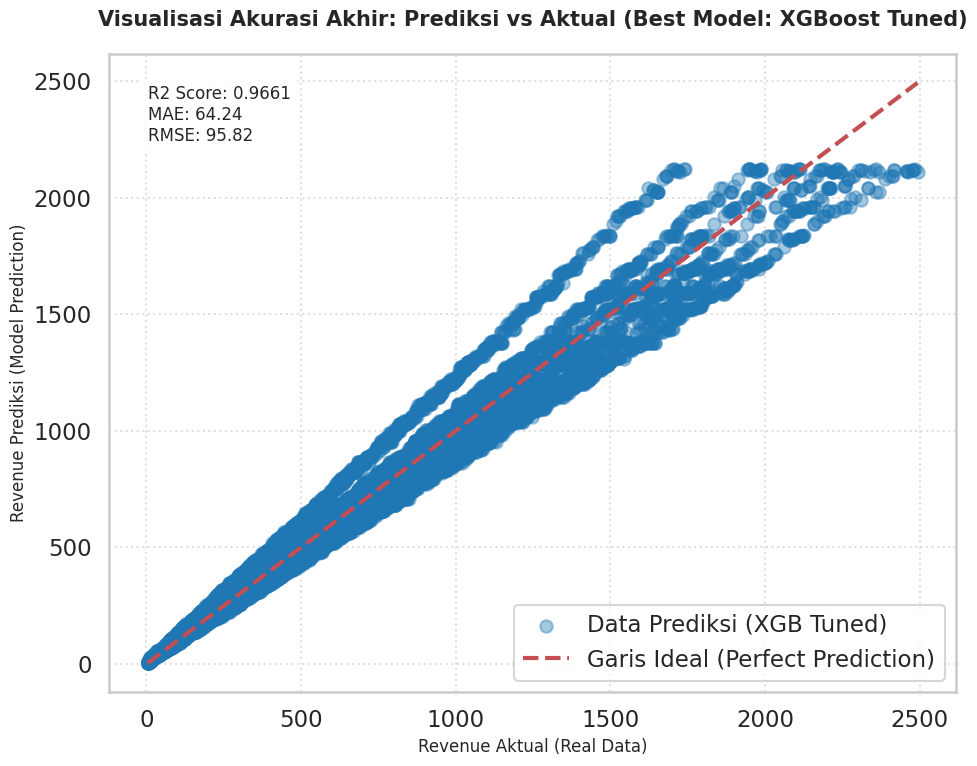

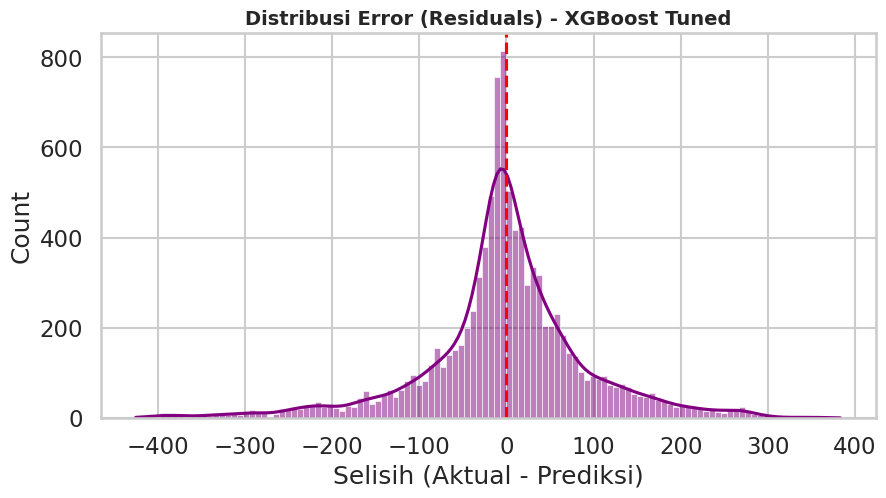

In [ ]:
# Menggunakan Model Terbaik Hasil Tuning (XGBoost Tuned)
# Dari hasil evaluasi, 'grid_xgb.best_estimator_' adalah model dengan R2 tertinggi (0.9661)
best_model = grid_xgb.best_estimator_
y_pred_best = best_model.predict(x_test_sel)

# Visualisasi Scatter Plot: Prediksi vs Aktual
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#1f77b4', label='Data Prediksi (XGB Tuned)')

# Garis Ideal (Diagonal)
max_val = max(y_test.max(), y_pred_best.max())
min_val = min(y_test.min(), y_pred_best.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Garis Ideal (Perfect Prediction)')

plt.text(min_val, max_val*0.9, f'R2 Score: 0.9661\nMAE: 64.24\nRMSE: 95.82',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.title('Visualisasi Akurasi Akhir: Prediksi vs Aktual (Best Model: XGBoost Tuned)', fontsize=15, pad=20)
plt.xlabel('Revenue Aktual (Real Data)', fontsize=12)
plt.ylabel('Revenue Prediksi (Model Prediction)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Visualisasi Residual (untuk mengecek error)
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred_best
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribusi Error (Residuals) - XGBoost Tuned', fontsize=14)
plt.xlabel('Selisih (Aktual - Prediksi)')
plt.show()


# Goal 2: Time Series Forecasting Bulanan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## Data Cleaning & Feature Engineering

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

# Pastikan revenue benar
df['total_revenue'] = df['price'] * df['quantity_sold'] * (1 - df['discount_percent']/100)

df = df.dropna()

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.50
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.63
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## Aggregasi Time Series (Monthly Revenue)

In [ ]:
# Melakukan agregasi Data ke Bulanan
df_monthly = df.resample('M', on='order_date')['total_revenue'].sum().to_frame()
df_monthly.columns = ['revenue']

df_monthly.head()

,revenue
order_date,
2022-01-31,1.419752e+06
2022-02-28,1.266715e+06
2022-03-31,1.392586e+06
2022-04-30,1.371956e+06
2022-05-31,1.374780e+06


##Visualisasi Time Series

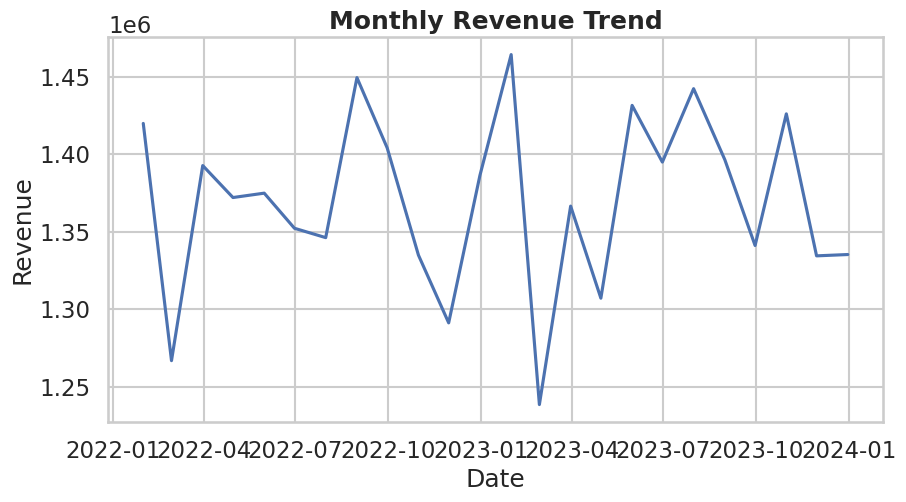

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df_monthly.index, df_monthly['revenue'])
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

## Stationarity Test (ADF Test)

In [ ]:
result = adfuller(df_monthly['revenue'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.894171238988351
p-value: 2.877440565211403e-07


inisght : data set stasionary

## Train Test Split

In [ ]:
# Split Data Kronologis (3 bulan terakhir untuk testing)
train = df_monthly.iloc[:-3]
test = df_monthly.iloc[-3:]

## Feature Engineering Lag

In [ ]:
# Feature Engineering untuk XGBoost (Lag Features)
df_ml = df_monthly.copy()

df_ml['lag_1'] = df_ml['revenue'].shift(1)
df_ml['lag_2'] = df_ml['revenue'].shift(2)
df_ml['rolling_mean_3'] = df_ml['revenue'].shift(1).rolling(3).mean()

df_ml = df_ml.dropna()

In [ ]:
train_ml = df_ml.iloc[:-3]
test_ml = df_ml.iloc[-3:]

## MODEL

In [ ]:
# ARIMA (Statistik)
model_arima = ARIMA(np.log(train['revenue']), order=(1,1,1))
model_arima_fit = model_arima.fit()

forecast_arima_log = model_arima_fit.forecast(steps=len(test))

forecast_arima = np.exp(forecast_arima_log)

In [ ]:
# ETS (Exponential Smoothing)
model_ets = ExponentialSmoothing(
    train['revenue'],
    trend='add',
    seasonal=None
)

model_ets_fit = model_ets.fit()

forecast_ets = model_ets_fit.forecast(steps=len(test))

In [ ]:
# XGBoost TS (Machine Learning)
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

model_xgb.fit(
    train_ml[['lag_1','lag_2','rolling_mean_3']],
    train_ml['revenue']
)

forecast_xgb = model_xgb.predict(
    test_ml[['lag_1','lag_2','rolling_mean_3']]
)

In [ ]:
# EVALUASI
def evaluate_model(true, pred, name):

    mae = mean_absolute_error(true, pred)
    mape = mean_absolute_percentage_error(true, pred)*100

    return pd.DataFrame({
        "Model":[name],
        "MAE":[round(mae,2)],
        "MAPE":[round(mape,2)]
    })

report = pd.concat([

    evaluate_model(test['revenue'], forecast_arima, "ARIMA"),
    evaluate_model(test['revenue'], forecast_ets, "ETS"),
    evaluate_model(test_ml['revenue'], forecast_xgb, "XGBoost")

])
print("Tabel Perbandingan Forecasting (Goal 2):")
print(report)

Tabel Perbandingan Forecasting (Goal 2):
     Model       MAE  MAPE
0    ARIMA  39738.01  2.89
0      ETS  46721.37  3.43
0  XGBoost  61190.13  4.42


## Visualisasi Perbandingan Model

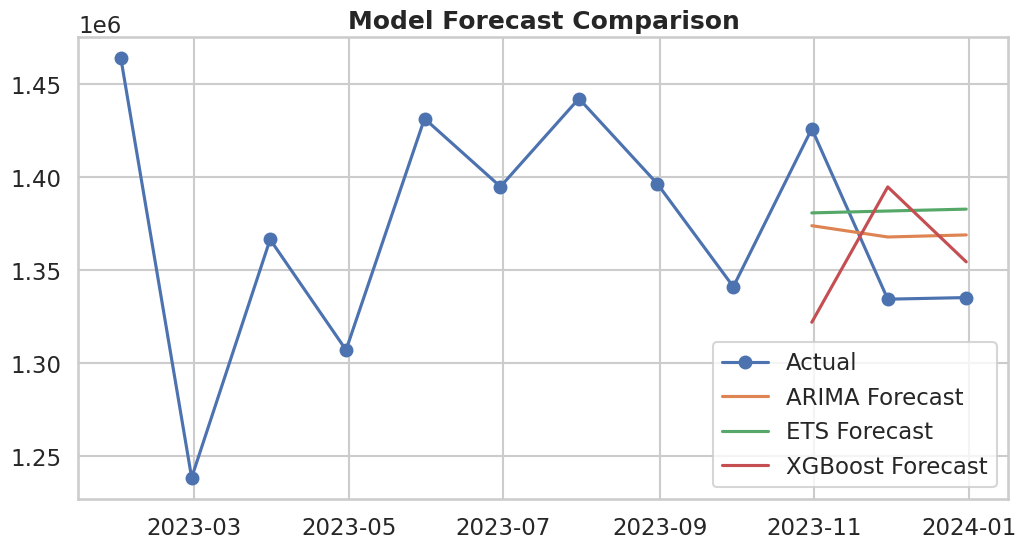

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_monthly.index[-12:], df_monthly['revenue'][-12:], label="Actual", marker='o')

plt.plot(test.index, forecast_arima, label="ARIMA Forecast")
plt.plot(test.index, forecast_ets, label="ETS Forecast")
plt.plot(test_ml.index, forecast_xgb, label="XGBoost Forecast")

plt.title("Model Forecast Comparison")
plt.legend()
plt.show()

## Model Terbaik

In [ ]:
best_model = report.sort_values("MAPE").iloc[0]['Model']

print("Best Model:", best_model)

Best Model: ARIMA


## Forecast Future (3 Bulan Kedepan)

In [ ]:
future_steps = 3

if best_model == "ARIMA":

    final_model = ARIMA(np.log(df_monthly['revenue']), order=(1,1,1)).fit()
    future_log = final_model.forecast(steps=future_steps)
    future_forecast = np.exp(future_log)

elif best_model == "ETS":

    final_model = ExponentialSmoothing(
        df_monthly['revenue'],
        trend='add'
    ).fit()

    future_forecast = final_model.forecast(steps=future_steps)

In [ ]:
# save model

import joblib

joblib.dump(final_model,"best_forecasting_model.pkl")

['best_forecasting_model.pkl']

Ringkasan Akhir Project:

Goal 1 (Per Order): Gunakan XGBoost (R2: 0.96) untuk memprediksi nilai transaksi individu berdasarkan quantity_sold dan price.

Goal 2 (Bulanan): Gunakan ARIMA (MAPE: 2.38%) untuk melakukan peramalan total pendapatan perusahaan setiap bulan.
